In [1]:

# imports
import os
import sys
import types
import json

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = fig_dpi
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  pio.renderers.default = "notebook_connected"
except Exception:
  pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass



# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
if r'G:\wjonasreger.github.io\projects\morphological_finite_state_transducer':
  os.chdir(r'G:\wjonasreger.github.io\projects\morphological_finite_state_transducer')

# reset state
%reset

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v
  
  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define


{"C:\\Users\\jonas\\AppData\\Local\\Programs\\Python\\Python39\\lib\\importlib\\_bootstrap.py": 1630373724.0, "C:\\Users\\jonas\\AppData\\Local\\Programs\\Python\\Python39\\lib\\importlib\\_bootstrap_external.py": 1630373724.0, "C:\\Users\\jonas\\AppData\\Local\\Programs\\Python\\Python39\\lib\\codecs.py": 1630373724.0, "C:\\Users\\jonas\\AppData\\Local\\Programs\\Python\\Python39\\lib\\encodings\\aliases.py": 1630373724.0, "C:\\Users\\jonas\\AppData\\Local\\Programs\\Python\\Python39\\lib\\encodings\\__init__.py": 1630373724.0, "C:\\Users\\jonas\\AppData\\Local\\Programs\\Python\\Python39\\lib\\encodings\\utf_8.py": 1630373724.0, "C:\\Users\\jonas\\AppData\\Local\\Programs\\Python\\Python39\\lib\\encodings\\latin_1.py": 1630373724.0, "C:\\Users\\jonas\\AppData\\Local\\Programs\\Python\\Python39\\lib\\abc.py": 1630373724.0, "C:\\Users\\jonas\\AppData\\Local\\Programs\\Python\\Python39\\lib\\io.py": 1630373724.0, "C:\\Users\\jonas\\AppData\\Local\\Programs\\Python\\Python39\\lib\\stat.p

C:\Users\jonas\AppData\Local\Temp/ipykernel_47964/1431407976.py:20: DeprecationWarning:

`set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`



In [2]:
#| code-fold: true
import os
import pandas as pd
import random
import sys

random.seed(22)

In [3]:
#| code-fold: true
df = pd.read_csv('https://raw.githubusercontent.com/wjonasreger/data/main/spanish_verbs.csv')

df_sample = pd.DataFrame()
for c in df['rule_id'].unique():
  df_temp = df.iloc[ list(df['rule_id'] == c), :]
  df_sample = pd.concat([df_sample, df_temp.sample(1)], axis=0)

df_sample.set_index('rule_id', inplace=True)
df_sample.sort_index(inplace=True)
df_sample

,rule_name,infinitive,conjugate
rule_id,,,
1,-Car : -Có,contramarchar,contramarchó
2,-Var : -Vó,coauspiciar,coauspició
3,-Cer : -Ció,torcer,torció
4,-Cir : -Ció,fundir,fundió
5,-guir : -guió,extinguir,extinguió
6,-quir : -quió,chasquir,chasquió
7,-ñer : -ñó,retañer,retañó
8,-ñir : -ñó,bruñir,bruñó
9,-Ver : -Vyó,roer,royó


In [4]:
#| code-fold: true
class Transition:
  def __init__(self, state_in, string_in, string_out, state_out):
    self.state_in = state_in
    self.string_in = string_in
    self.state_out = state_out
    self.string_out = string_out

  def equals(self, t):
    if self.state_in == t.state_in \
    and self.string_in == t.string_in \
    and self.state_out == t.state_out \
    and self.string_out == t.string_out:
      return True
    else:
      return False

In [5]:
#| code-fold: true
class State:
  def __init__(self, id, is_final, FST):
    self.id = id  # integer id of the state
    self.is_final = is_final  # indicator that this is the final state
    self.transitions = dict() # map string_in to a set of all possible transitions
    self.FST = FST

  def addTransition(self, string_in, string_out, state_out):
    # create new transition
    new_transition = Transition(self, string_in, string_out, state_out)
    if string_in in self.transitions:
      for t in self.transitions[string_in]:
        if t.equals(new_transition):
          return
      self.transitions[string_in].add(new_transition)
    else:
      self.transitions[string_in] = set([])
      self.transitions[string_in].add(new_transition)
  
  def parseInputFromStartState(self, string_in, debug=False):
    parse_tuple = ("", self.id)
    parses = []
    (accept, string_parses) = self.parseInput(string_in, debug)
    if accept:
      for p in string_parses:
        complete_parse = [parse_tuple]
        complete_parse.extend(p)
        parses.append(complete_parse)
    return (accept, parses)

  def parseInput(self, string_in, debug=False):
      parses = []
      if debug:
        print("parseInput: state: ", self.id, " parsing: " , string_in)
      
      # case 1: no suffix
      if string_in == "":
        epsilon_parses = []
        epsilon_accepted = False
        # try all epsilon transitions
        if "" in self.transitions:
          trans_set = self.transitions[""]
          for t in trans_set:
            string_out = t.string_out
            to_state_id = t.state_out
            to_state = self.FST.all_states[to_state_id]
            parse_tuple = (string_out, to_state_id)
            (suffix_accepted, suffix_parses) = to_state.parseInput(string_in)
            if suffix_accepted:
              epsilon_accepted = True
              if suffix_parses == []: # accepts
                parse_s = [parse_tuple]
                epsilon_parses.append(parse_s)
              else:
                for s in suffix_parses:
                  parse_s = [parse_tuple]
                  parse_s.extend(s)
                  epsilon_parses.append(parse_s)
        # if epsilon is accepted, add all its parses
        if epsilon_accepted:
          parses.extend(epsilon_parses)
        # if this is a final state, add an empty parse
        if self.is_final or parses != []:
          if debug:
            print("Accepted in state ", self.id)
          return (True, parses)
        else:
          if debug:
            print("Rejected in state ", self.id)
          return (False, None)

      # case 2: non-empty suffix - there needs to be one suffix that parses
      has_accepted_suffix = False;
      for i in range(0,len(string_in)+1):
        prefix = string_in[0:i]
        suffix = string_in[i:len(string_in)]
        if debug:
          print("\t prefix: \'", prefix, "\' I=", i)
        if prefix in self.transitions:
          if debug:
            print("\t prefix: ", prefix,  "suffix: ", suffix, "I=", i)
          trans_set = self.transitions[prefix]
          for t in trans_set:
            string_out = t.string_out
            to_state_id = t.state_out
            to_state = self.FST.all_states[to_state_id]
            parse_tuple = (string_out, to_state_id)
            (suffix_accepted, suffix_parses) = to_state.parseInput(suffix)
            if suffix_accepted:
              has_accepted_suffix = True
              if suffix_parses == []:
                parse_s = [parse_tuple]
                parses.append(parse_s)
                this_prefix_parses = True
              for s in suffix_parses:
                parse_s = [parse_tuple]
                parse_s.extend(s)
                parses.append(parse_s)

      if has_accepted_suffix:
        return (True, parses)
      else:
        return (False, None)
                          
  def printState(self):
    if self.is_final:
      FINAL = "FINAL"
    else: FINAL = ""
    print("State", self.id, FINAL)
    for string_in in self.transitions:
      trans_list = self.transitions[string_in]
      for t in trans_list:
        print("\t", string_in, ":", t.string_out, " => ", t.state_out)

In [6]:
#| code-fold: true
class FST:
  def __init__(self, init_state_name="INIT"):
    self.n_states = 0
    self.init_state = State(init_state_name, False, self) 
    self.all_states = dict()
    self.all_states[init_state_name] = self.init_state
      
  def addState(self, name, is_final=False):
    if name in self.all_states:
      print("ERROR addState: state", name, "exists already")
      sys.exit()
    else:  
      new_state = State(name, is_final, self)
      self.all_states[name] = new_state

  def addTransition(self, state_in_name, string_in, string_out, state_out_name):
    if (len(string_in) > 1):
      print("ERROR: addTransition: input string ", string_in, " is longer than one character")
      sys.exit()
    if state_in_name not in self.all_states:
      print("ERROR: addTransition: state ", state_in_name, " does not exist")
      sys.exit()
    if state_out_name not in self.all_states:
      print("ERROR: addTransition: state ", state_out_name, " does not exist")
      sys.exit()
    state_in = self.all_states[state_in_name]
    state_in.addTransition(string_in, string_out, state_out_name)

  # map string to itself
  def addSelfTransition(self, state_in_name, string_in, state_out_name):
    if state_in_name not in self.all_states:
      print("ERROR: addSetTransition: state ", state_in_name, " does not exist")
      sys.exit()
    if state_out_name not in self.all_states:
      print("ERROR: addSetTransition: state ", state_out_name, " does not exist")
      sys.exit()
    self.addTransition(state_in_name, string_in, string_in, state_out_name)

  # epsilon:epsilon
  def addEpsilonTransition(self, state_in_name, state_out_name):
    if state_in_name not in self.all_states:
      print("ERROR: addEpsilonTransition: state ", state_in_name, " does not exist")
      sys.exit()
    if state_out_name not in self.all_states:
      print("ERROR: addEpsilonTransition: state ", state_out_name, " does not exist")
      sys.exit()
    if state_in_name == state_out_name:
      print("ERROR: epsilon loop")
      sys.exit()
    state_in = self.all_states[state_in_name]
    state_in.addTransition("", "", state_out_name)

  # map every element in string_in_set to itself
  def addSetTransition(self, state_in_name, string_in_set, state_out_name):
    if state_in_name not in self.all_states:
      print("ERROR: addSetTransition: state ", state_in_name, " does not exist")
      sys.exit()
    if state_out_name not in self.all_states:
      print("ERROR: addSetTransition: state ", state_out_name, " does not exist")
      sys.exit()
    for s in string_in_set:
      self.addTransition(state_in_name, s, s, state_out_name)

  # map every element in string_in_set to string_out
  def addSetToStringTransition(self, state_in_name, string_in_set, string_out, state_out_name):
    if state_in_name not in self.all_states:
      print("ERROR: addSetDummyTransition: state ", state_in_name, " does not exist")
      sys.exit()
    if state_out_name not in self.all_states:
      print("ERROR: addSetDummyTransition: state ", state_out_name, " does not exist")
      sys.exit()
    for s in string_in_set:
      self.addTransition(state_in_name, s, string_out, state_out_name)
  
  # map every element in string_in_set to string_out=""
  def addSetToEpsilonTransition(self, state_in_name, string_in_set, state_out_name):
    if state_in_name not in self.all_states:
      print("ERROR: addSetEpsilonTransition: state ", state_in_name, " does not exist")
      sys.exit()
    if state_out_name not in self.all_states:
      print("ERROR: addSetEpsionTransition: state ", state_out_name, " does not exist")
      sys.exit()
    for s in string_in_set:
      self.addTransition(state_in_name, s, "", state_out_name)

  # map every key element in string_in_dict to its value
  def addDictTransition(self, state_in_name, string_in_dict, state_out_name):
    if state_in_name not in self.all_states:
      print("ERROR: addSetTransition: state ", state_in_name, " does not exist")
      sys.exit()
    if state_out_name not in self.all_states:
      print("ERROR: addSetTransition: state ", state_out_name, " does not exist")
      sys.exit()
    for key, value in string_in_dict.items():
      self.addTransition(state_in_name, key, value, state_out_name)
          
  def parseInput(self, string_in, show_states=False, debug=False):
    string_in = string_in.rstrip('\n')
    (can_parse, all_parses)  = self.init_state.parseInputFromStartState(string_in, debug)
    all_parses_as_string = ""
    if can_parse:
      for parse in all_parses:
        for tuple in parse:
          string_out, state_out = tuple
          all_parses_as_string += string_out
        if show_states:
          all_parses_as_string += "\t  States: "
          i = 0
          for tuple in parse:
            i += 1
            string_out, state_out = tuple
            all_parses_as_string += state_out
            if i < len(parse):
              all_parses_as_string += " => "
          all_parses_as_string += "; "
  
      return True, all_parses_as_string
    else:
      return False, "FAIL"

  def parseInputList(self, verb_list, show_states=False, debug=False):
    n_parses = 0
    total_strings = 0
    res = []
    for verb in verb_list:
      total_strings += 1
      can_parse, parse = self.parseInput(verb, show_states, debug)
      res += [parse]
      if can_parse:
        n_parses += 1
    fraction = n_parses / total_strings
    print(n_parses, "/", total_strings, "=", str(fraction * 100)+'%', "of examples parsed") 
    return res

  def printFST(self):
    print("Printing FST", str(self))
    for state_id in self.all_states:
      state = self.all_states[state_id]
      state.printState()

In [7]:
'''
structure = {
    '_init': 'INIT', # the initial state
    '_accept': 'EOW', # an accepting state
    '_states': ['EPS'],
    '_transitions': {
        '_regular': 
          [{'state_in_name':'', 'string_in':'', 'string_out':'', 'state_out_name':''}],
        '_self': 
          [{'state_in_name':'', 'string_in':'', 'state_out_name':''}],
        '_epsilon': 
          [{'state_in_name':'', 'state_out_name':''}],
        '_set': 
          [{'state_in_name':'', 'string_in_set':'', 'state_out_name':''}],
        '_set2string': 
          [{'state_in_name':'', 'string_in_set':'', 'string_out':'', 'state_out_name':''}]],
        '_set2epsilon': 
          [{'state_in_name':'', 'string_in_set':'', 'state_out_name':''}],
        '_dict': 
          [{'state_in_name':'', 'string_in_dict':'', 'state_out_name':''}]
    }
}
'''

def buildFST(structure):
  # instantiate FST
  f = FST(init_state_name=structure['_init'])
  # add accepting state
  f.addState(name=structure['_accept'], is_final=True)
  # add all states
  for s in structure['_states']:
    f.addState(name=s)
  # add regular transitions
  if structure['_transitions']['_regular'] is not None:
    for t in structure['_transitions']['_regular']:
      f.addTransition(t['state_in_name'], t['string_in'], t['string_out'], t['state_out_name'])
  # add self transitions
  if structure['_transitions']['_self'] is not None:
    for t in structure['_transitions']['_self']:
      f.addSelfTransition(t['state_in_name'], t['string_in'], t['state_out_name'])
  # add epsilon transitions
  if structure['_transitions']['_epsilon'] is not None:
    for t in structure['_transitions']['_epsilon']:
      f.addEpsilonTransition(t['state_in_name'], t['state_out_name'])
  # add set transitions
  if structure['_transitions']['_set'] is not None:
    for t in structure['_transitions']['_set']:
      f.addSetTransition(t['state_in_name'], t['string_in_set'], t['state_out_name'])
  # add set to string transitions
  if structure['_transitions']['_set2string'] is not None:
    for t in structure['_transitions']['_set2string']:
      f.addSetToStringTransition(t['state_in_name'], t['string_in_set'], t['string_out'], t['state_out_name'])
  # add set to epsilon transitions
  if structure['_transitions']['_set2epsilon'] is not None:
    for t in structure['_transitions']['_set2epsilon']:
      f.addSetToEpsilonTransition(t['state_in_name'], t['string_in_set'], t['state_out_name'])
  # add dictionary transitions
  if structure['_transitions']['_dict'] is not None:
    for t in structure['_transitions']['_dict']:
      f.addDictTransition(t['state_in_name'], t['string_in_dict'], t['state_out_name'])
  return f

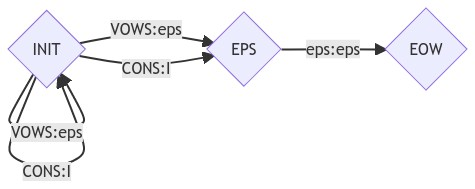

In [8]:
%matplotlib inline

import base64
import requests, io
from PIL import Image
import matplotlib.pyplot as plt

graph = """
flowchart LR
    %% initial state
    INIT{INIT} --"VOWS:eps"--> INIT
    INIT --"CONS:I"--> INIT

    %% epsilon state
    INIT --"VOWS:eps"--> EPS{EPS}
    INIT --"CONS:I"--> EPS

    %% accepting state
    EPS --"eps:eps"--> EOW{EOW}
"""

graphbytes = graph.encode("utf-8")
base64_bytes = base64.b64encode(graphbytes)
base64_string = base64_bytes.decode("utf-8")
background_color = '?bgColor=!white'
requested_content = requests.get('https://mermaid.ink/img/' + base64_string + background_color).content
image = Image.open(io.BytesIO(requested_content))
image

In [9]:
A2Z = set('abcdefghijklmnopqrstuvwxyz')
VOWS = set('aeiou')
CONS = A2Z-VOWS

cons_count_structure = {
    '_init': 'INIT', # the initial state
    '_accept': 'EOW', # an accepting state
    '_states': ['EPS'],
    '_transitions': {
        '_regular': None,
        '_self': None,
        '_epsilon': [
            # If see empty string, then end of word
            {'state_in_name':'EPS', 'state_out_name':'EOW'}
        ],
        '_set': None,
        '_set2string': [
            # # maps consonants to 'I'
            {'state_in_name':'INIT', 'string_in_set':CONS, 'string_out':'I', 'state_out_name':'INIT'},
            {'state_in_name':'INIT', 'string_in_set':CONS, 'string_out':'I', 'state_out_name':'EPS'}
        ],
        '_set2epsilon': [
            # maps vowels to ''
            {'state_in_name':'INIT', 'string_in_set':VOWS, 'state_out_name':'INIT'},
            {'state_in_name':'INIT', 'string_in_set':VOWS, 'state_out_name':'EPS'}
        ],
        '_dict': None
    }
}

In [10]:
# FST for consonant counts
cons_count_fst = buildFST(cons_count_structure)

# example of debugging results for parsing the word "soccer"
fst_parses = cons_count_fst.parseInputList(['soccer'], show_states=True, debug=True)

parseInput: state:  INIT  parsing:  soccer
	 prefix: '  ' I= 0
	 prefix: ' s ' I= 1
	 prefix:  s suffix:  occer I= 1
	 prefix: ' so ' I= 2
	 prefix: ' soc ' I= 3
	 prefix: ' socc ' I= 4
	 prefix: ' socce ' I= 5
	 prefix: ' soccer ' I= 6
1 / 1 = 100.0% of examples parsed


In [11]:
# input word list
sentence = ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

# parse results and the state paths
fst_parses = cons_count_fst.parseInputList(sentence, show_states=True, debug=False)

df_parses = pd.DataFrame({'words':sentence, 'parsings':fst_parses})
df_parses['results'] = df_parses.parsings.apply(lambda x: x.split('\t ')[0])
df_parses['states'] = df_parses.parsings.apply(lambda x: x.split('\t ')[1])
df_parses.drop(['states', 'parsings'], axis=1, inplace=True)
df_parses.set_index('words', inplace=True)
df_parses.T

9 / 9 = 100.0% of examples parsed


words,the,quick,brown,fox,jumps,over,the,lazy,dog
results,II,III,IIII,II,IIII,II,II,III,II


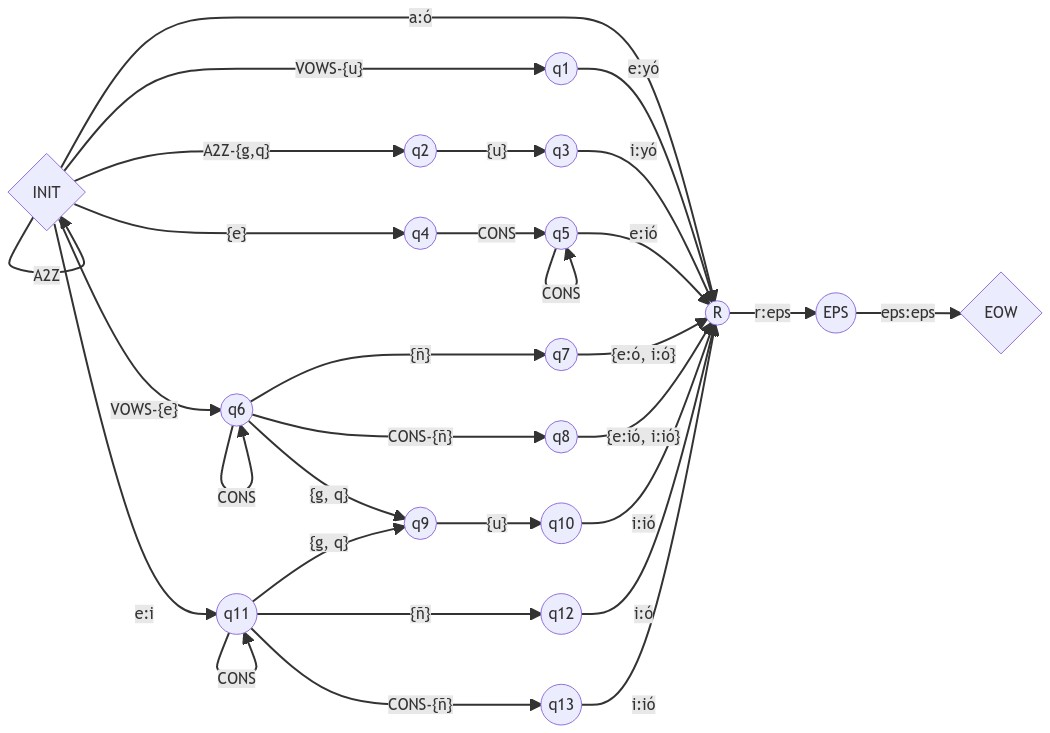

In [12]:
%matplotlib inline

import base64
import requests, io
from PIL import Image
import matplotlib.pyplot as plt

graph = """
flowchart LR
    %% Initial state
    q0{INIT} --A2Z--> q0
    %% Accepting states
    R((R)) --"r:eps"--> EPS((EPS))
    EPS --"eps:eps"--> EOW{EOW}

    %% -Var verbs
    q0 --a:ó--> R

    %% -Ver verbs
    q0 --"VOWS-{u}"--> q1((q1))
    q1 --"e:yó"--> R

    %% -Vir verbs
    q0 --"A2Z-{g,q}"--> q2((q2))
    q2 --"{u}"--> q3((q3))
    q3 --"i:yó"--> R
    
    %% -Cer (includes ñ for "e" verbs)
    q0 --"{e}"--> q4((q4))
    q4 --"CONS"--> q5((q5))
    q5 --"CONS"--> q5
    q5 --"e:ió"--> R

    %% -Cer, -Cir verbs
    q0 --"VOWS-{e}"--> q6((q6))
    q6 --"CONS"--> q6
    q6 --"{ñ}"--> q7((q7))
    q7 --"{e:ó, i:ó}"--> R %% -ñer, -ñir verbs
    q6 --"CONS-{ñ}"--> q8((q8))
    q8 --"{e:ió, i:ió}"--> R %% -Cer, -Cir verbs (excludes ñ)
    q6 --"{g, q}"--> q9((q9))
    q9 --"{u}"--> q10((q10))
    q10((q10)) --"i:ió"--> R %% -guir, -quir verbs (also -eguir verbs from state q11)

    %% eXir verbs
    q0 --e:i--> q11((q11))
    q11 --"CONS"--> q11
    q11 --"{ñ}"--> q12((q12))
    q12 --"i:ó"--> R %% -eñir verbs
    q11 --"CONS-{ñ}"--> q13((q13))
    q13 --"i:ió"--> R %% -eCir, -eCCir, -eCCCir verbs
    q11 --"{g, q}"--> q9

"""

graphbytes = graph.encode("utf-8")
base64_bytes = base64.b64encode(graphbytes)
base64_string = base64_bytes.decode("utf-8")
background_color = '?bgColor=!white'
requested_content = requests.get('https://mermaid.ink/img/' + base64_string + background_color).content
image = Image.open(io.BytesIO(requested_content))
image

In [13]:
A2Z = set('abcçdefghijklmnopqrstuvwxyzáéíóúñü')
VOWS = set('aeiouáéíóúü')
CONS = A2Z-VOWS

spanish_structure = {
    '_init': 'INIT', # the initial state
    '_accept': 'EOW', # an accepting state
    '_states': ['EPS', 'R', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'q9', 'q10', 'q11', 'q12', 'q13'],
    '_transitions': {
        '_regular': [
            # Transition on final r in infinitive - replace with empty string
            {'state_in_name':'R', 'string_in':'r', 'string_out':'', 'state_out_name':'EPS'},
            # -Var verbs
            {'state_in_name':'INIT', 'string_in':'a', 'string_out':'ó', 'state_out_name':'R'},
            # -Ver verbs
            {'state_in_name':'q1', 'string_in':'e', 'string_out':'yó', 'state_out_name':'R'},
            # -Vir verbs
            {'state_in_name':'q3', 'string_in':'i', 'string_out':'yó', 'state_out_name':'R'},
            # -Cer verbs (includes ñ)
            {'state_in_name':'q5', 'string_in':'e', 'string_out':'ió', 'state_out_name':'R'},
            # -guir, -quir verbs (also -eguir verbs from state q11)
            {'state_in_name':'q10', 'string_in':'i', 'string_out':'ió', 'state_out_name':'R'},
            # vowel raising 'e' to 'i'
            {'state_in_name':'INIT', 'string_in':'e', 'string_out':'i', 'state_out_name':'q11'},
            # -eñir verbs
            {'state_in_name':'q12', 'string_in':'i', 'string_out':'ó', 'state_out_name':'R'},
            # -eCir, -eCCir, -eCCCir verbs
            {'state_in_name':'q13', 'string_in':'i', 'string_out':'ió', 'state_out_name':'R'}
        ],
        '_self': [
            # e.g., compare: construir ==> construyó, delinguir ==> delinquió
            {'state_in_name':'q2', 'string_in':'u', 'state_out_name':'q3'},
            # e.g., prevents: trascender ==> trascindió (correct: trascendió)
            {'state_in_name':'INIT', 'string_in':'e', 'state_out_name':'q4'},
            # e.g., prevents: tañer ==> tañió (correct: tañó)
            {'state_in_name':'q6', 'string_in':'ñ', 'state_out_name':'q7'},
            # e.g., prevents: seguir ==> siguyó (correct: siguió)
            {'state_in_name':'q9', 'string_in':'u', 'state_out_name':'q10'},
            # e.g., prevents: heñir ==> hiñió (correct: hiñó)
            {'state_in_name':'q11', 'string_in':'ñ', 'state_out_name':'q12'}
        ],
        '_epsilon': [
            # If see empty string, then end of word
            {'state_in_name':'EPS', 'state_out_name':'EOW'}
        ],
        '_set': [
            # self-loop on all letters to transition through stem
            {'state_in_name':'INIT', 'string_in_set':A2Z, 'state_out_name':'INIT'}, # u?
            # check for stems ending with vowel for -er verbs. e.g., leer ==> leyó
            {'state_in_name':'INIT', 'string_in_set':VOWS-{'u'}, 'state_out_name':'q1'}, # u?
            # check for stems ending with vowel for -ir verbs (excluding -guir, -quir verbs)
            # e.g., construir ==> construyó
            {'state_in_name':'INIT', 'string_in_set':A2Z-{'g', 'q'}, 'state_out_name':'q2'},
            # requires consonant between 'e' in stem and -er ending (no vowels in between).
            # e.g., compare: temer ==> temió, leer ==> leyó
            # prevents: leer ==> leió (correct: leyó)
            {'state_in_name':'q4', 'string_in_set':CONS, 'state_out_name':'q5'},
            # allows additional consonants between 'e' in stem and -er ending (no vowels in between).
            # e.g., converger ==> convergió
            {'state_in_name':'q5', 'string_in_set':CONS, 'state_out_name':'q5'},
            # ignores verbs with 'e' as last vowel in stem
            {'state_in_name':'INIT', 'string_in_set':VOWS-{'e'}, 'state_out_name':'q6'},
            # enforces previous transition such that the vowel is truly the last in the stem
            # i.e., terminating paths if vowel reappears before verb ending
            {'state_in_name':'q6', 'string_in_set':CONS, 'state_out_name':'q6'},
            # ignores verbs with stems that end with 'ñ'
            # prevents: tañer ==> tañió (correct: tañó)
            {'state_in_name':'q6', 'string_in_set':CONS-{'ñ'}, 'state_out_name':'q8'},
            # accepting potential -guir, -quir verbs
            {'state_in_name':'q6', 'string_in_set':{'g', 'q'}, 'state_out_name':'q9'},
            # enforces that 'e' is last vowel of potential -ir verb for vowel raising
            {'state_in_name':'q11', 'string_in_set':CONS, 'state_out_name':'q11'},
            # ignores verbs with stems that end with 'ñ'
            # prevents: heñir ==> hiñió (correct: hiñó)
            {'state_in_name':'q11', 'string_in_set':CONS-{'ñ'}, 'state_out_name':'q13'},
            # accepting potential -eguir verbs
            {'state_in_name':'q11', 'string_in_set':{'g', 'q'}, 'state_out_name':'q9'}
        ],
        '_set2string': None,
        '_set2epsilon': None,
        '_dict': [
            # -ñer and -ñir verbs
            {'state_in_name':'q7', 'string_in_dict':{'e':'ó', 'i':'ó'}, 'state_out_name':'R'},
            # -Cer and -Cir verbs (excludes ñ)
            {'state_in_name':'q8', 'string_in_dict':{'e':'ió', 'i':'ió'}, 'state_out_name':'R'}
        ]
    }
}

In [14]:
spanish_fst = buildFST(spanish_structure)
fst_parses = spanish_fst.parseInputList([verb for verb in df.infinitive])

df_parses = pd.concat([df, pd.DataFrame(fst_parses)], axis=1)
df_parses
df_parses.columns = list(df.columns) + ['parse']
df_parses['correct'] = df_parses.conjugate == df_parses.parse
df_parses.sample(5)

3295 / 3295 = 100.0% of examples parsed


,rule_id,rule_name,infinitive,conjugate,parse,correct
3097,2,-Var : -Vó,timonear,timoneó,timoneó,True
2976,1,-Car : -Có,sobrepoblar,sobrepobló,sobrepobló,True
1988,1,-Car : -Có,intricar,intricó,intricó,True
3292,2,-Var : -Vó,zurear,zureó,zureó,True
766,1,-Car : -Có,confederar,confederó,confederó,True


In [15]:
print("Overall Accuracy:", str(df_parses.correct.mean() * 100) + '%')

df_results = df_parses[['rule_id', 'rule_name', 'correct']].groupby(['rule_id', 'rule_name']).agg(['sum', 'count', 'mean'])
df_results.columns = ['correct', 'total', 'accuracy']
df_results.accuracy = df_results.accuracy.apply(lambda x: str(x * 100) + '%')
df_results.sort_index(inplace=True)
df_results.reset_index(inplace=True)
df_results.set_index('rule_id', inplace=True)

df_results

Overall Accuracy: 100.0%


,rule_name,correct,total,accuracy
rule_id,,,,
1,-Car : -Có,2371,2371,100.0%
2,-Var : -Vó,559,559,100.0%
3,-Cer : -Ció,150,150,100.0%
4,-Cir : -Ció,130,130,100.0%
5,-guir : -guió,2,2,100.0%
6,-quir : -quió,3,3,100.0%
7,-ñer : -ñó,2,2,100.0%
8,-ñir : -ñó,6,6,100.0%
9,-Ver : -Vyó,8,8,100.0%


In [16]:
df_sample = pd.DataFrame()
for c in df_parses['rule_id'].unique():
  df_temp = df_parses.iloc[list(df_parses['rule_id'] == c), :]
  df_sample = pd.concat([df_sample, df_temp.sample(1)], axis=0)

df_sample.set_index('rule_id', inplace=True)
df_sample.sort_index(inplace=True)
df_sample

,rule_name,infinitive,conjugate,parse,correct
rule_id,,,,,
1,-Car : -Có,vengar,vengó,vengó,True
2,-Var : -Vó,ansiar,ansió,ansió,True
3,-Cer : -Ció,sobrentender,sobrentendió,sobrentendió,True
4,-Cir : -Ció,polir,polió,polió,True
5,-guir : -guió,distinguir,distinguió,distinguió,True
6,-quir : -quió,delinquir,delinquió,delinquió,True
7,-ñer : -ñó,retañer,retañó,retañó,True
8,-ñir : -ñó,astriñir,astriñó,astriñó,True
9,-Ver : -Vyó,leer,leyó,leyó,True
